# MakFleet — Exploratory Data Analysis
**BIS 3205 | Makerere University Campus Bodaboda Fleet**

This notebook performs structured EDA on the MakFleet Spatio-Temporal Knowledge Graph.
All data is queried live from Neo4j and the enriched JSONL files on disk.

Sections:
1. Dataset Overview
2. Temporal Analysis — Demand by Hour, Day, Semester
3. Anomaly Breakdown — Event Types and Severity
4. Spatial Analysis — Hotspot Intersections
5. Driver Risk Profiles
6. Speed Distribution by Event Type
7. Semester Comparison (Concept Drift)
8. Knowledge Graph Statistics

In [15]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('').resolve()))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY = True
except ImportError:
    PLOTLY = False

from config.settings import PROCESSED_DIR, RAW_DIR, NEO4J_URI, NEO4J_AUTH

try:
    from neo4j import GraphDatabase
    _driver = GraphDatabase.driver(NEO4J_URI, auth=NEO4J_AUTH)
    _driver.verify_connectivity()
    NEO4J_OK = True
    print('Neo4j connected')
except Exception as e:
    NEO4J_OK = False
    print(f'Neo4j not available: {e}')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
COLORS = {
    'harsh_braking': '#e74c3c',
    'rapid_acceleration': '#e67e22',
    'speeding': '#c0392b',
    'idling': '#3498db',
    'normal_travel': '#95a5a6',
    'safe_stop': '#27ae60',
}
print('Setup complete')

Neo4j connected
Setup complete


## 1. Dataset Overview

In [16]:
# Load enriched events from disk
print('Loading enriched events...')
records = []
with open(PROCESSED_DIR / 'enriched_events.jsonl') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date
df['day_of_week'] = df['timestamp'].dt.day_name()

# Fleet metadata
with open(RAW_DIR / 'fleet_meta.json') as f:
    fleet = json.load(f)
drivers_df = pd.DataFrame(fleet['drivers'])

print(f'Total records:     {len(df):,}')
print(f'Semester 1:        {len(df[df.semester==1]):,}')
print(f'Semester 2:        {len(df[df.semester==2]):,}')
print(f'Total anomalies:   {df.is_anomaly.sum():,} ({100*df.is_anomaly.mean():.1f}%)')
print(f'Vehicles:          {df.vehicle_id.nunique()}')
print(f'Drivers:           {df.driver_id.nunique()}')
print(f'Date range Sem1:   {df[df.semester==1].timestamp.min().date()} to {df[df.semester==1].timestamp.max().date()}')
print(f'Date range Sem2:   {df[df.semester==2].timestamp.min().date()} to {df[df.semester==2].timestamp.max().date()}')
print(f'\nEvent type breakdown:')
print(df.event_type.value_counts().to_string())

Loading enriched events...
Total records:     826,260
Semester 1:        496,559
Semester 2:        329,701
Total anomalies:   72,592 (8.8%)
Vehicles:          15
Drivers:           15
Date range Sem1:   2024-01-15 to 2024-04-13
Date range Sem2:   2024-08-01 to 2024-09-30

Event type breakdown:
event_type
normal_travel         753668
speeding               63222
rapid_acceleration      8635
harsh_braking            735


## 2. Temporal Analysis

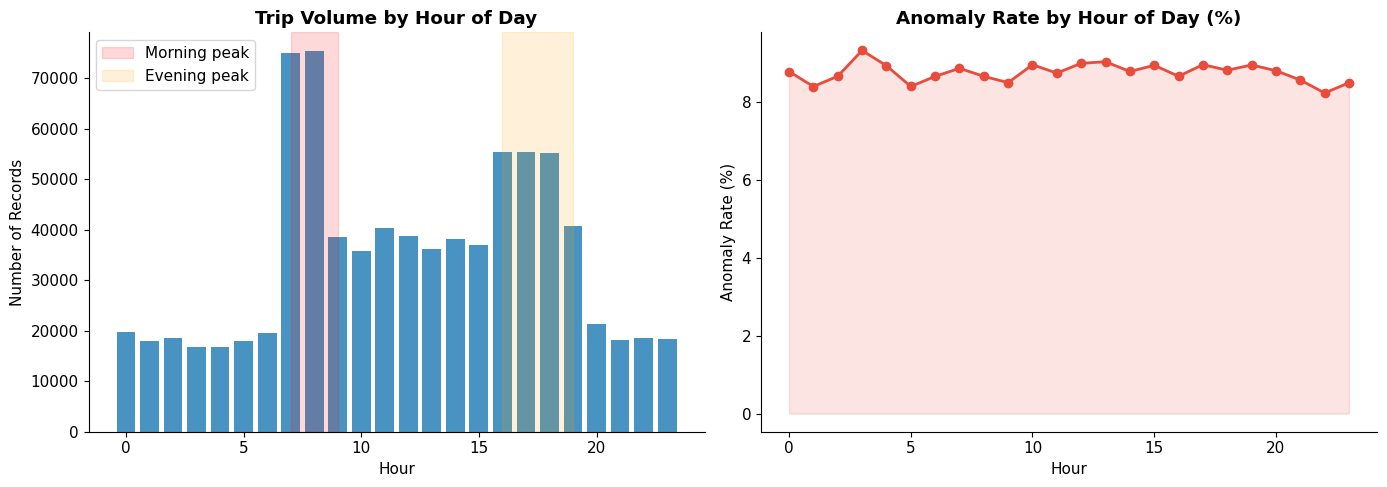

Saved: eda_temporal_hourly.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly demand
hourly = df.groupby('hour').size().reset_index(name='trips')
axes[0].bar(hourly['hour'], hourly['trips'], color='#2980b9', alpha=0.85)
axes[0].set_title('Trip Volume by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Records')
axes[0].axvspan(7, 9, alpha=0.15, color='red', label='Morning peak')
axes[0].axvspan(16, 19, alpha=0.15, color='orange', label='Evening peak')
axes[0].legend()

# Anomaly rate by hour
hourly_anom = df.groupby('hour')['is_anomaly'].mean() * 100
axes[1].plot(hourly_anom.index, hourly_anom.values, 'o-', color='#e74c3c', linewidth=2)
axes[1].fill_between(hourly_anom.index, hourly_anom.values, alpha=0.15, color='#e74c3c')
axes[1].set_title('Anomaly Rate by Hour of Day (%)', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Anomaly Rate (%)')

plt.tight_layout()
plt.savefig('eda_temporal_hourly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_temporal_hourly.png')

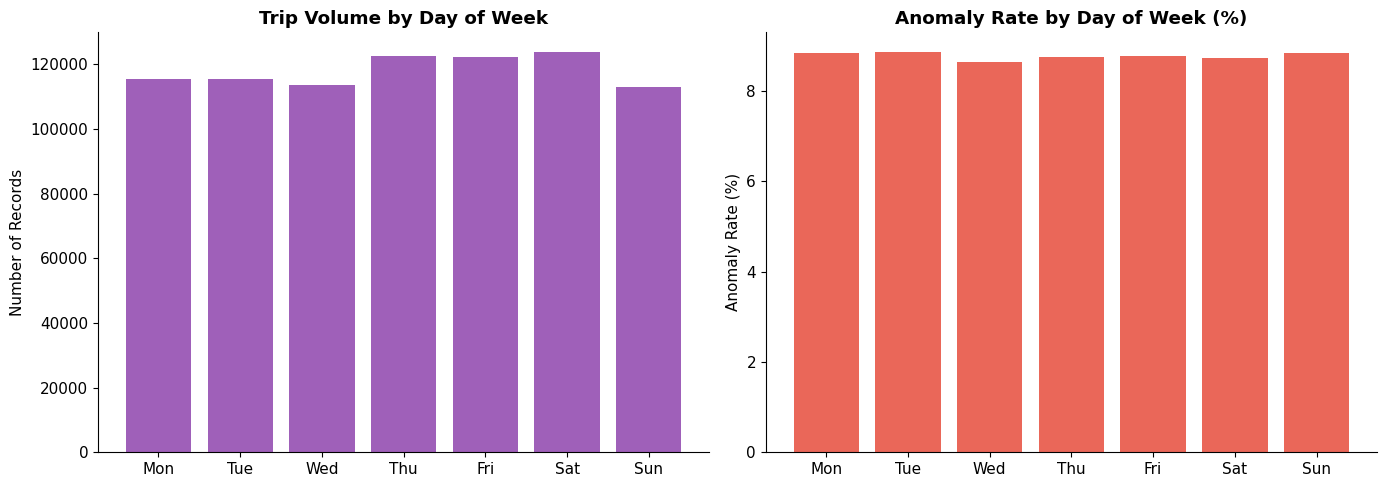

In [18]:
# Day of week pattern
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week').size().reindex(dow_order)
dow_anom = (df.groupby('day_of_week')['is_anomaly'].mean() * 100).reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(7), dow.values, color='#8e44ad', alpha=0.85)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels([d[:3] for d in dow_order])
axes[0].set_title('Trip Volume by Day of Week', fontweight='bold')
axes[0].set_ylabel('Number of Records')

axes[1].bar(range(7), dow_anom.values, color='#e74c3c', alpha=0.85)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in dow_order])
axes[1].set_title('Anomaly Rate by Day of Week (%)', fontweight='bold')
axes[1].set_ylabel('Anomaly Rate (%)')

plt.tight_layout()
plt.savefig('eda_temporal_dow.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Anomaly Breakdown

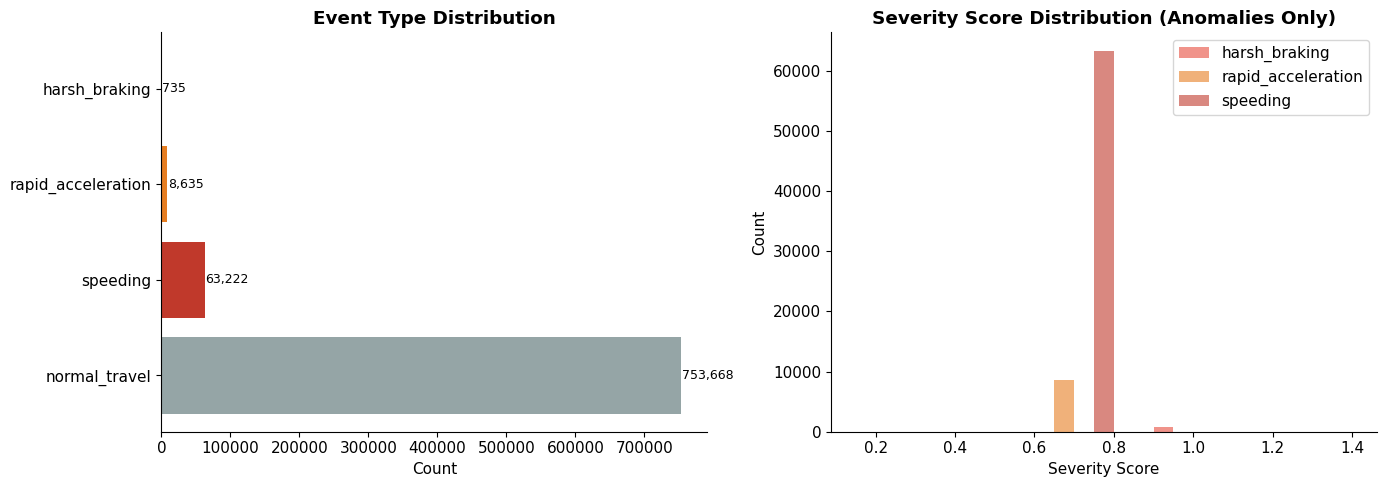

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Event type counts
etype = df.event_type.value_counts()
colors = [COLORS.get(e, '#7f8c8d') for e in etype.index]
axes[0].barh(etype.index, etype.values, color=colors)
axes[0].set_title('Event Type Distribution', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(etype.values):
    axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=9)

# Severity score distribution for anomalies only
anom_df = df[df.is_anomaly]
for etype_name, grp in anom_df.groupby('event_type'):
    axes[1].hist(grp['severity_score'], bins=20, alpha=0.6,
                 label=etype_name, color=COLORS.get(etype_name, '#7f8c8d'))
axes[1].set_title('Severity Score Distribution (Anomalies Only)', fontweight='bold')
axes[1].set_xlabel('Severity Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_anomaly_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

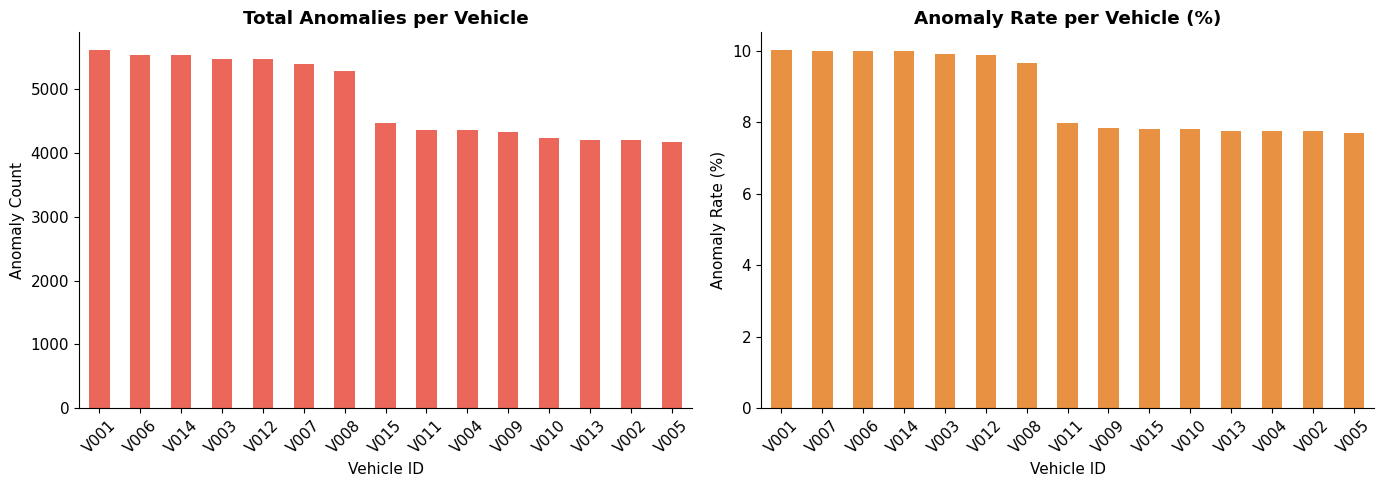

In [20]:
# Anomalies per vehicle
vehicle_anom = df[df.is_anomaly].groupby('vehicle_id').size().sort_values(ascending=False)
vehicle_total = df.groupby('vehicle_id').size()
vehicle_rate = (vehicle_anom / vehicle_total * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vehicle_anom.plot(kind='bar', ax=axes[0], color='#e74c3c', alpha=0.85)
axes[0].set_title('Total Anomalies per Vehicle', fontweight='bold')
axes[0].set_xlabel('Vehicle ID')
axes[0].set_ylabel('Anomaly Count')
axes[0].tick_params(axis='x', rotation=45)

vehicle_rate.plot(kind='bar', ax=axes[1], color='#e67e22', alpha=0.85)
axes[1].set_title('Anomaly Rate per Vehicle (%)', fontweight='bold')
axes[1].set_xlabel('Vehicle ID')
axes[1].set_ylabel('Anomaly Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_vehicle_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Spatial Analysis — Hotspot Intersections

In [7]:
if NEO4J_OK:
    with _driver.session() as s:
        result = s.run("""
            MATCH (e:TelematicsEvent)-[:LOCATED_AT]->(i:Intersection)
            RETURN i.osm_id AS node_id, i.lat AS lat, i.lon AS lon,
                   i.landmark_name AS name, i.landmark_type AS ltype,
                   count(e) AS total_events,
                   sum(CASE WHEN e.is_anomaly THEN 1 ELSE 0 END) AS anomaly_events,
                   avg(e.speed_kmh) AS avg_speed
            ORDER BY total_events DESC LIMIT 20
        """)
        spatial_df = pd.DataFrame([dict(r) for r in result])
    
    print('Top 10 busiest intersections:')
    print(spatial_df[['node_id','name','ltype','total_events','anomaly_events','avg_speed']].head(10).to_string(index=False))
else:
    # Fallback from disk
    spatial_df = df.groupby('matched_edge_u').agg(
        total_events=('event_id','count'),
        anomaly_events=('is_anomaly','sum'),
        avg_speed=('speed_kmh','mean'),
        lat=('lat','mean'),
        lon=('lon','mean')
    ).reset_index().rename(columns={'matched_edge_u':'node_id'}).sort_values('total_events', ascending=False)
    print(spatial_df.head(10).to_string(index=False))

Top 10 busiest intersections:
   node_id name ltype  total_events  anomaly_events  avg_speed
2081071399                    71172            5591  30.009266
 576559393                    67641            5173  30.035127
6227732217                    50609            3947  30.018535
 669207672                    50404           23801  48.402250
4234701599                    45607            4604  30.998756
6233150197                    36023            3078  30.378458
  33648189                    34169            2628  29.969778
 560562839                    30001           10884  56.353928
3799734363                    28620            2197  49.722798
 669207673                    27768            2107  30.017941


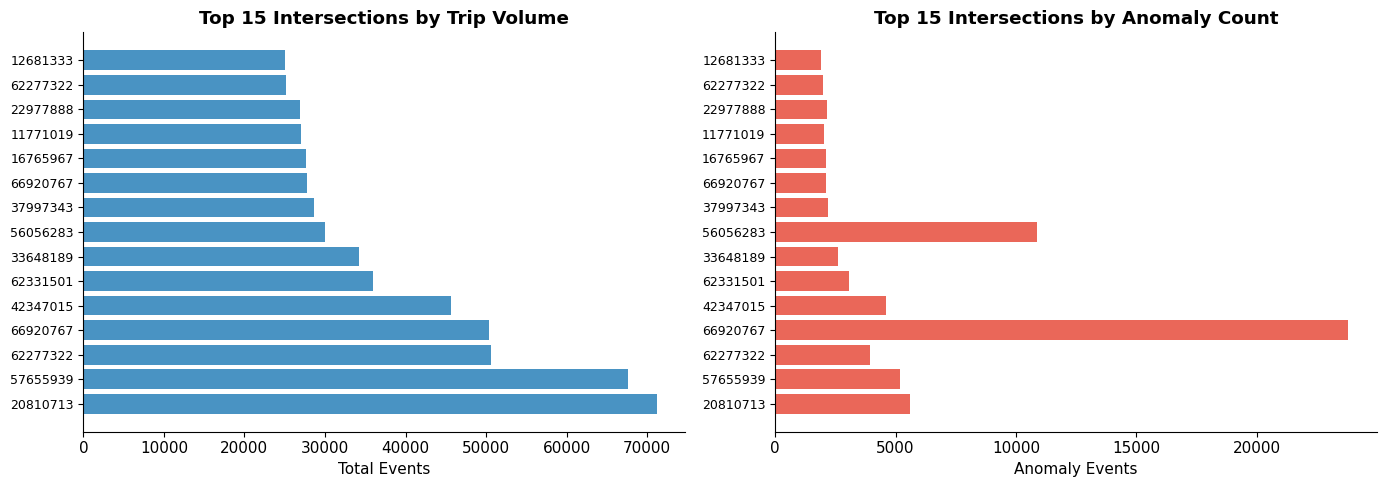

In [8]:
if not spatial_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top15 = spatial_df.head(15).copy()
    labels = [str(r['name']) if r.get('name') else str(r['node_id'])[:8] for _, r in top15.iterrows()]

    axes[0].barh(range(len(top15)), top15['total_events'].values, color='#2980b9', alpha=0.85)
    axes[0].set_yticks(range(len(top15)))
    axes[0].set_yticklabels(labels, fontsize=9)
    axes[0].set_title('Top 15 Intersections by Trip Volume', fontweight='bold')
    axes[0].set_xlabel('Total Events')

    axes[1].barh(range(len(top15)), top15['anomaly_events'].values, color='#e74c3c', alpha=0.85)
    axes[1].set_yticks(range(len(top15)))
    axes[1].set_yticklabels(labels, fontsize=9)
    axes[1].set_title('Top 15 Intersections by Anomaly Count', fontweight='bold')
    axes[1].set_xlabel('Anomaly Events')

    plt.tight_layout()
    plt.savefig('eda_spatial_hotspots.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Driver Risk Profiles

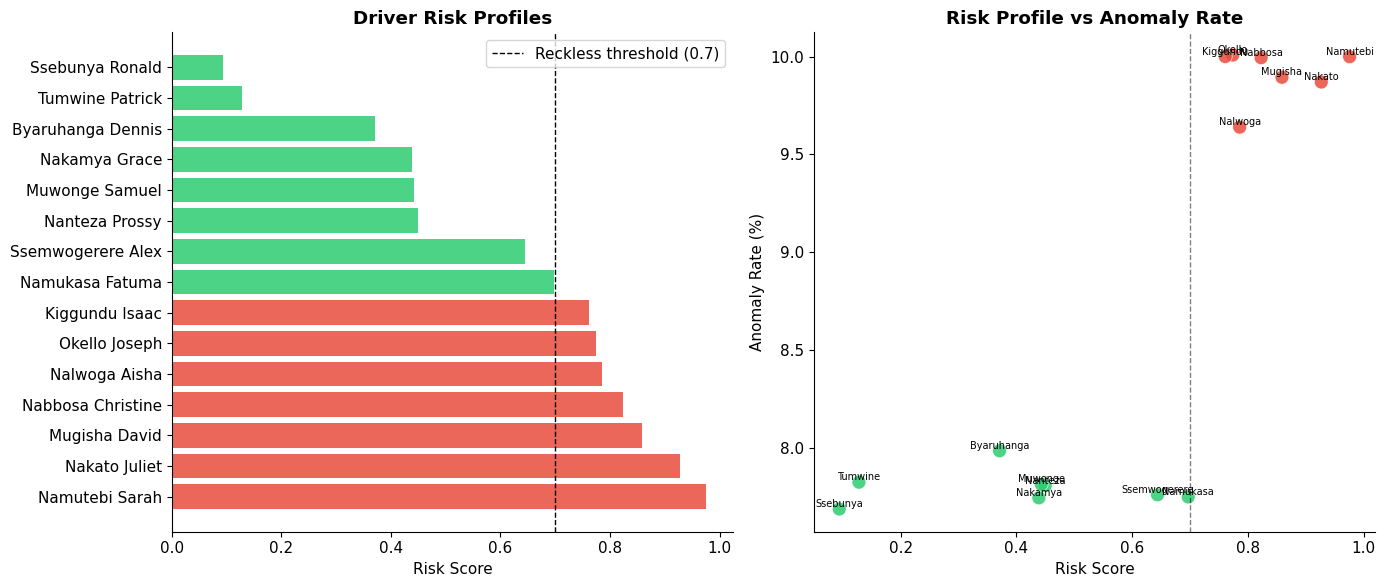


Reckless drivers (risk > 0.7): 7
Safe drivers (risk <= 0.7):    8

Mean anomaly rate — reckless: 9.9%
Mean anomaly rate — safe:     7.8%


In [9]:
driver_stats = df.groupby('driver_id').agg(
    total_records=('event_id', 'count'),
    anomaly_count=('is_anomaly', 'sum'),
    avg_speed=('speed_kmh', 'mean'),
    avg_severity=('severity_score', 'mean'),
).reset_index()
driver_stats['anomaly_rate'] = driver_stats['anomaly_count'] / driver_stats['total_records'] * 100
driver_stats = driver_stats.merge(drivers_df[['driver_id','name','risk_profile','is_reckless']], on='driver_id')
driver_stats = driver_stats.sort_values('risk_profile', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bar_colors = ['#e74c3c' if r else '#2ecc71' for r in driver_stats['is_reckless']]
axes[0].barh(driver_stats['name'], driver_stats['risk_profile'], color=bar_colors, alpha=0.85)
axes[0].axvline(0.7, color='black', linestyle='--', linewidth=1, label='Reckless threshold (0.7)')
axes[0].set_title('Driver Risk Profiles', fontweight='bold')
axes[0].set_xlabel('Risk Score')
axes[0].legend()

axes[1].scatter(driver_stats['risk_profile'], driver_stats['anomaly_rate'],
                c=bar_colors, s=100, alpha=0.85, edgecolors='white', linewidth=0.5)
for _, row in driver_stats.iterrows():
    axes[1].annotate(row['name'].split()[0], (row['risk_profile'], row['anomaly_rate']),
                     fontsize=7, ha='center', va='bottom')
axes[1].axvline(0.7, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Risk Profile vs Anomaly Rate', fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Anomaly Rate (%)')

plt.tight_layout()
plt.savefig('eda_driver_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nReckless drivers (risk > 0.7): {driver_stats['is_reckless'].sum()}")
print(f"Safe drivers (risk <= 0.7):    {(~driver_stats['is_reckless']).sum()}")
print(f"\nMean anomaly rate — reckless: {driver_stats[driver_stats.is_reckless]['anomaly_rate'].mean():.1f}%")
print(f"Mean anomaly rate — safe:     {driver_stats[~driver_stats.is_reckless]['anomaly_rate'].mean():.1f}%")

## 6. Speed Distribution by Event Type

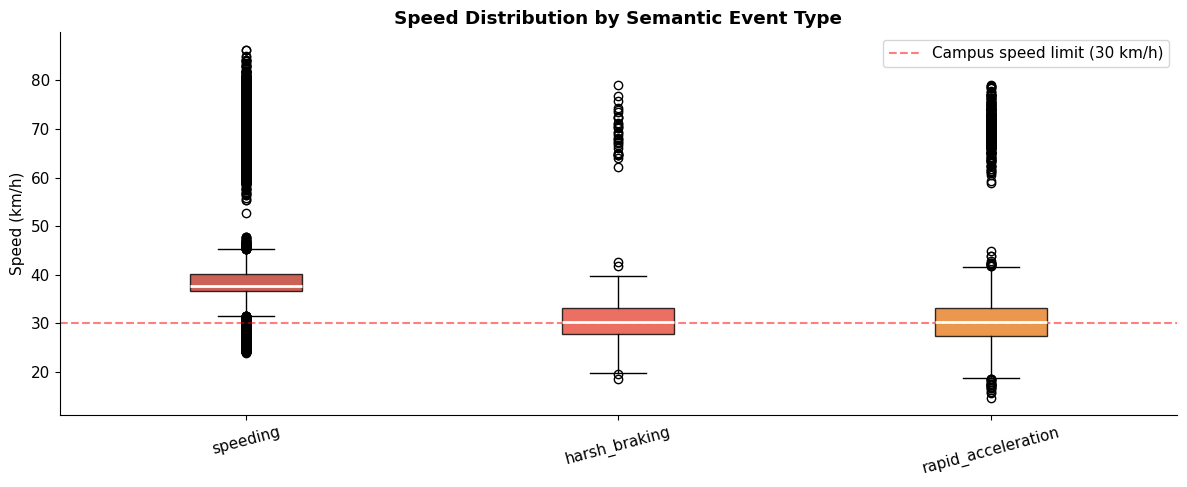


Median speed by event type:
event_type
speeding              37.75
harsh_braking         30.34
rapid_acceleration    30.21
normal_travel         29.79


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

event_types = [e for e in df.event_type.unique() if e != 'normal_travel']
data_to_plot = [df[df.event_type == e]['speed_kmh'].dropna().values for e in event_types]

bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, etype in zip(bp['boxes'], event_types):
    patch.set_facecolor(COLORS.get(etype, '#7f8c8d'))
    patch.set_alpha(0.8)

ax.set_xticks(range(1, len(event_types)+1))
ax.set_xticklabels(event_types, rotation=15)
ax.set_title('Speed Distribution by Semantic Event Type', fontweight='bold')
ax.set_ylabel('Speed (km/h)')
ax.axhline(30, color='red', linestyle='--', alpha=0.5, label='Campus speed limit (30 km/h)')
ax.legend()

plt.tight_layout()
plt.savefig('eda_speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMedian speed by event type:')
print(df.groupby('event_type')['speed_kmh'].median().sort_values(ascending=False).to_string())

## 7. Semester Comparison — Concept Drift

Semester comparison:
 semester  total_records  anomaly_count  avg_speed  avg_severity  anomaly_rate
        1         496559          43455  31.478253      0.064690      8.751226
        2         329701          29137  31.524364      0.065418      8.837401


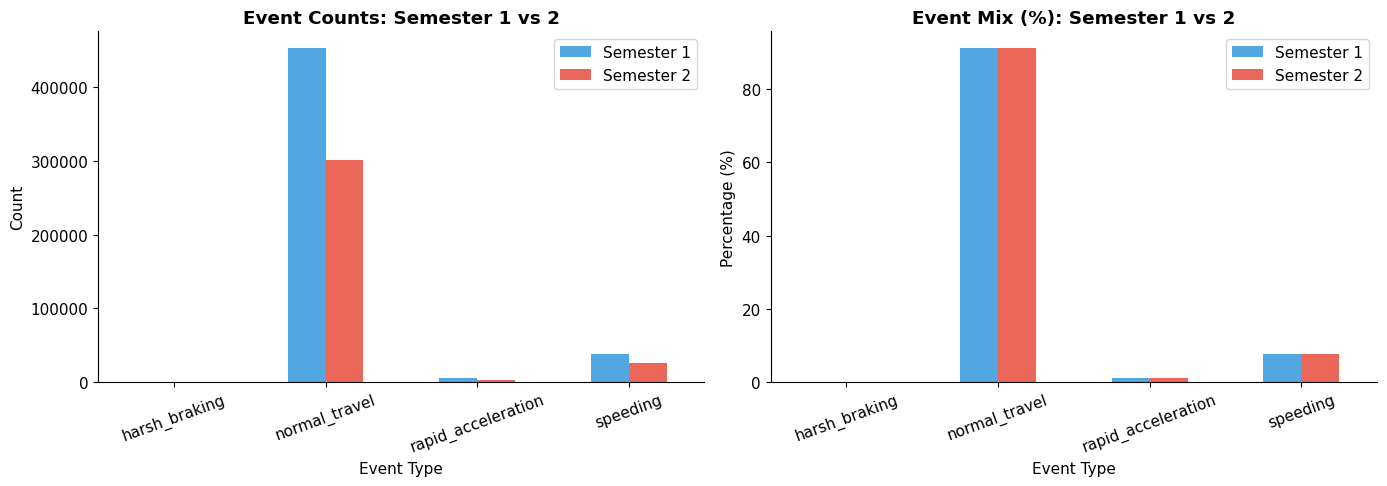

In [11]:
sem_stats = df.groupby('semester').agg(
    total_records=('event_id', 'count'),
    anomaly_count=('is_anomaly', 'sum'),
    avg_speed=('speed_kmh', 'mean'),
    avg_severity=('severity_score', 'mean'),
).reset_index()
sem_stats['anomaly_rate'] = sem_stats['anomaly_count'] / sem_stats['total_records'] * 100

print('Semester comparison:')
print(sem_stats.to_string(index=False))

# Event type breakdown per semester
sem_etype = df.groupby(['semester','event_type']).size().unstack(fill_value=0)
sem_etype_pct = sem_etype.div(sem_etype.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sem_etype.T.plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c'], alpha=0.85)
axes[0].set_title('Event Counts: Semester 1 vs 2', fontweight='bold')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(['Semester 1', 'Semester 2'])

sem_etype_pct.T.plot(kind='bar', ax=axes[1], color=['#3498db','#e74c3c'], alpha=0.85)
axes[1].set_title('Event Mix (%): Semester 1 vs 2', fontweight='bold')
axes[1].set_xlabel('Event Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(['Semester 1', 'Semester 2'])

plt.tight_layout()
plt.savefig('eda_semester_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Knowledge Graph Statistics

=== Knowledge Graph Node Counts ===
           label   count
 TelematicsEvent 1379217
     RoadSegment     495
    Intersection     213
         Vehicle      15
          Driver      15
ProvenanceAnchor       2

=== Relationship Counts ===
   rel_type   count
 LOCATED_AT 1379712
  CAUSED_BY 1379217
ADJACENT_TO     495
     DRIVES      15


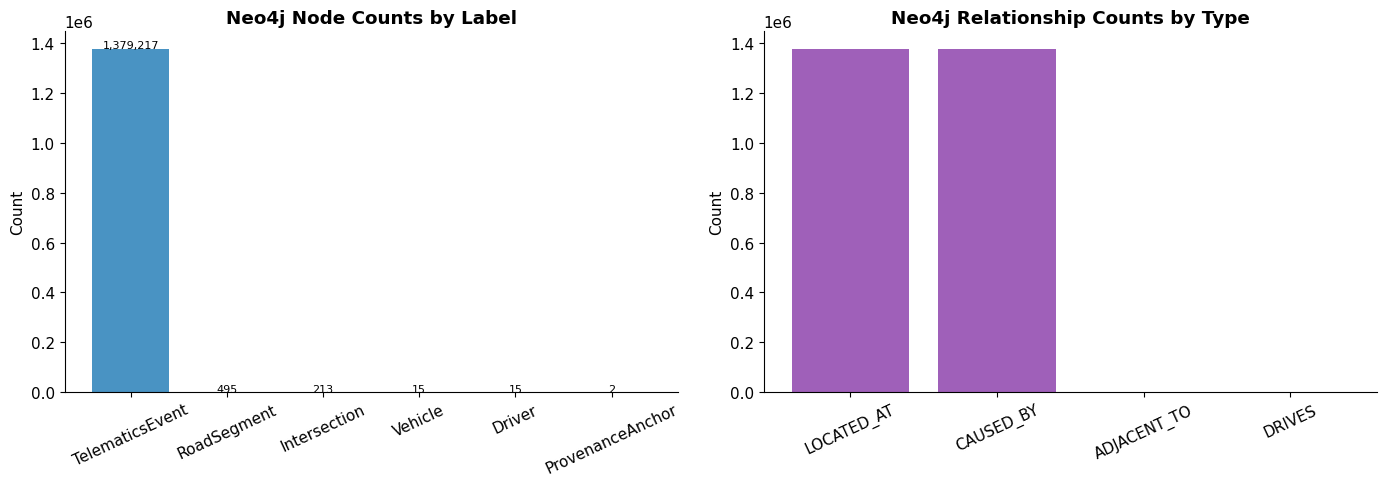

In [12]:
if NEO4J_OK:
    with _driver.session() as s:
        label_counts = s.run("""
            MATCH (n) RETURN labels(n)[0] AS label, count(n) AS count
            ORDER BY count DESC
        """)
        lc = pd.DataFrame([dict(r) for r in label_counts])

        rel_counts = s.run("""
            MATCH ()-[r]->() RETURN type(r) AS rel_type, count(r) AS count
            ORDER BY count DESC
        """)
        rc = pd.DataFrame([dict(r) for r in rel_counts])

    print('=== Knowledge Graph Node Counts ===')
    print(lc.to_string(index=False))
    print('\n=== Relationship Counts ===')
    print(rc.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(lc['label'], lc['count'], color='#2980b9', alpha=0.85)
    axes[0].set_title('Neo4j Node Counts by Label', fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=25)
    for i, (_, row) in enumerate(lc.iterrows()):
        axes[0].text(i, row['count'] + 500, f"{row['count']:,}", ha='center', fontsize=8)

    axes[1].bar(rc['rel_type'], rc['count'], color='#8e44ad', alpha=0.85)
    axes[1].set_title('Neo4j Relationship Counts by Type', fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=25)

    plt.tight_layout()
    plt.savefig('eda_kg_stats.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Neo4j not connected — skipping KG stats')

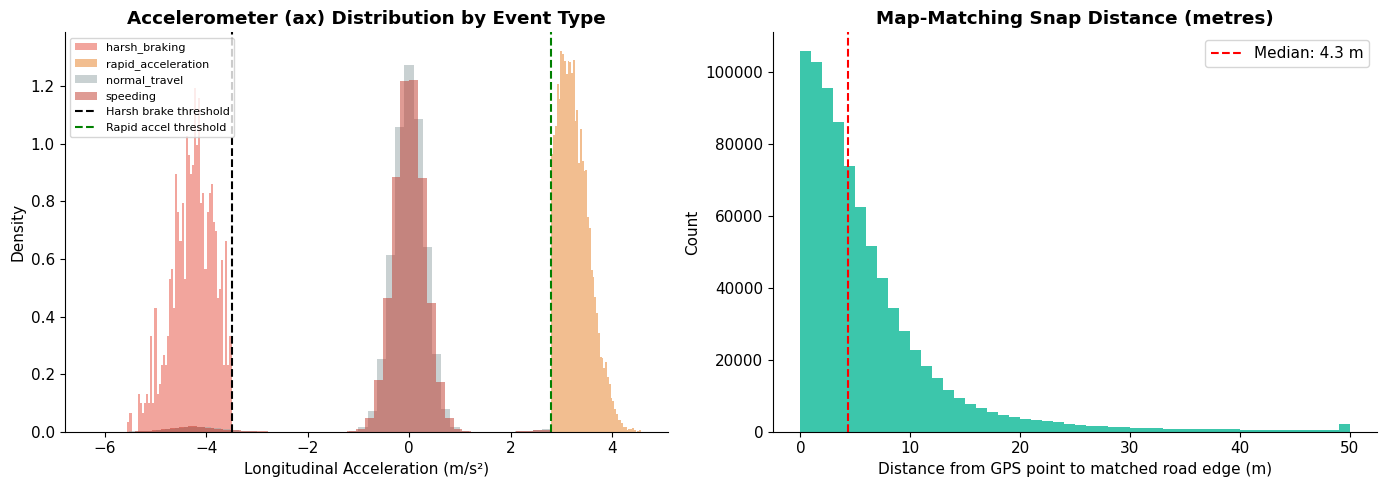

Map-matching confidence — mean: 0.906
Snap distance — median: 4.3 m, 95th pct: 19.2 m


In [13]:
# Accelerometer distribution — key for anomaly validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for etype in ['harsh_braking', 'rapid_acceleration', 'normal_travel', 'speeding']:
    subset = df[df.event_type == etype]['ax'].dropna()
    if len(subset) > 0:
        axes[0].hist(subset, bins=50, alpha=0.5, label=etype,
                     color=COLORS.get(etype, '#7f8c8d'), density=True)

axes[0].axvline(-3.5, color='black', linestyle='--', linewidth=1.5, label='Harsh brake threshold')
axes[0].axvline(2.8, color='green', linestyle='--', linewidth=1.5, label='Rapid accel threshold')
axes[0].set_title('Accelerometer (ax) Distribution by Event Type', fontweight='bold')
axes[0].set_xlabel('Longitudinal Acceleration (m/s²)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# GPS noise validation
df['snap_dist'] = df['snap_distance_m'].clip(0, 50)
axes[1].hist(df['snap_dist'].dropna(), bins=50, color='#1abc9c', alpha=0.85)
axes[1].set_title('Map-Matching Snap Distance (metres)', fontweight='bold')
axes[1].set_xlabel('Distance from GPS point to matched road edge (m)')
axes[1].set_ylabel('Count')
axes[1].axvline(df['snap_dist'].median(), color='red', linestyle='--',
                label=f"Median: {df['snap_dist'].median():.1f} m")
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_sensor_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Map-matching confidence — mean: {df['map_match_confidence'].mean():.3f}")
print(f"Snap distance — median: {df['snap_distance_m'].median():.1f} m, 95th pct: {df['snap_distance_m'].quantile(0.95):.1f} m")

In [14]:
print('=== EDA Summary ===')
print(f'Total records analysed:     {len(df):,}')
print(f'Total anomalies:            {df.is_anomaly.sum():,} ({100*df.is_anomaly.mean():.1f}%)')
print(f'Peak demand hour:           {df.groupby("hour").size().idxmax()}:00')
print(f'Most common anomaly:        {df[df.is_anomaly].event_type.mode()[0]}')
print(f'Highest risk driver:        {driver_stats.iloc[0]["name"]} (risk={driver_stats.iloc[0]["risk_profile"]:.2f})')
print(f'Avg map-match confidence:   {df["map_match_confidence"].mean():.3f}')
print(f'\nSaved figures:')
for f in Path('.').glob('eda_*.png'):
    print(f'  {f.name}')

=== EDA Summary ===
Total records analysed:     826,260
Total anomalies:            72,592 (8.8%)
Peak demand hour:           8:00
Most common anomaly:        speeding
Highest risk driver:        Namutebi Sarah (risk=0.98)
Avg map-match confidence:   0.906

Saved figures:
  eda_anomaly_breakdown.png
  eda_driver_risk.png
  eda_kg_stats.png
  eda_semester_comparison.png
  eda_sensor_validation.png
  eda_spatial_hotspots.png
  eda_speed_distribution.png
  eda_temporal_dow.png
  eda_temporal_hourly.png
  eda_vehicle_anomalies.png
